In [7]:
import sqlite3
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [8]:
os.getcwd()

'C:\\Users\\Tom\\Documents\\Project working directory\\Coursework\\Python files'

In [9]:
os.chdir('C:\\Users\\Tom\\Documents\\Project working directory\\Coursework\\Python files')

# Creating Database

In [10]:
try:
    os.remove('../Python files/py_airline3.db')
except OSError:
    pass

conn = sqlite3.connect('../Python files/py_+airline3.db')

# Creating table using airline data from 2001 to 2002

In [11]:
c = conn.cursor()

In [12]:
c.execute('''
CREATE TABLE arrived (
  Year int,
  Month int,
  DayofMonth int,
  DayOfWeek int,
  DepTime  int,
  CRSDepTime int,
  ArrTime int,
  CRSArrTime int,
  UniqueCarrier varchar(5),
  FlightNum int,
  TailNum varchar(8),
  ActualElapsedTime int,
  CRSElapsedTime int,
  AirTime int,
  ArrDelay int,
  DepDelay int,
  Origin varchar(3),
  Dest varchar(3),
  Distance int,
  TaxiIn int,
  TaxiOut int,
  Cancelled int,
  CancellationCode varchar(1),
  Diverted varchar(1),
  CarrierDelay int,
  WeatherDelay int,
  NASDelay int,
  SecurityDelay int,
  LateAircraftDelay int
)
''')

conn.commit()

OperationalError: table arrived already exists

In [13]:
for year in range(2001, 2002):
    print('Processing: ', year)
    arrived1 = pd.read_csv("../Python files/"+str(year)+".csv.bz2", encoding='latin-1')    
    arrived1.to_sql('arrived1', con = conn, if_exists = 'append', index = False)
for year in range(2002, 2003):
    print('Processing: ', year)
    arrived2 = pd.read_csv("../Python files/"+str(year)+".csv.bz2", encoding='latin-1')    
    arrived2.to_sql('arrived2', con = conn, if_exists = 'append', index = False)
conn.commit()

Processing:  2001
Processing:  2002


# Generating table for 2001

In [42]:
df1 = c.execute('''
SELECT Dest , COUNT(Dest) 
FROM arrived1
GROUP BY Dest
''').fetchall()
df2 = pd.DataFrame(df1)
df2.columns = ['Destination','Flight_count']
df2

In [47]:
df3 = c.execute('''
SELECT Dest , COUNT(Dest) 
FROM arrived2
GROUP BY Dest
''').fetchall()
df4 = pd.DataFrame(df3)
df4.columns = ['Destination','Flight_count']
df4

,Destination,Flight_count
0,ABE,12540
1,ABI,14610
2,ABQ,217416
3,ACT,14346
4,ACY,6
...,...,...
214,TYS,24444
215,VPS,14118
216,WRG,4356
217,XNA,30996


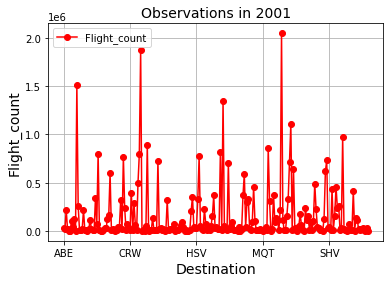

In [54]:
df2.plot(kind='line', x='Destination',y='Flight_count', color='red', marker='o')
plt.title('Observations in 2001', fontsize=14)
plt.xlabel('Destination', fontsize=14)
plt.ylabel('Flight_count', fontsize=14)
plt.grid(True)
plt.show()

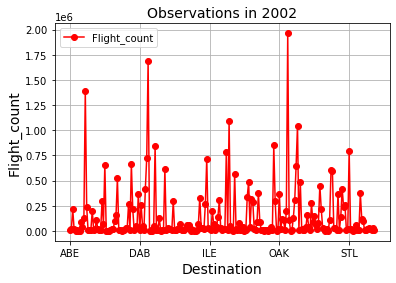

In [56]:
df4.plot(kind='line', x='Destination',y='Flight_count', color='red', marker='o')
plt.title('Observations in 2002', fontsize=14)
plt.xlabel('Destination', fontsize=14)
plt.ylabel('Flight_count', fontsize=14)
plt.grid(True)
plt.show()

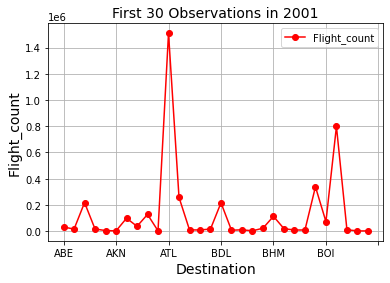

In [58]:
df2.head(30).plot(kind='line', x='Destination',y='Flight_count', color='red', marker='o')
plt.title('First 30 Observations in 2001', fontsize=14)
plt.xlabel('Destination', fontsize=14)
plt.ylabel('Flight_count', fontsize=14)
plt.grid(True)
plt.show()

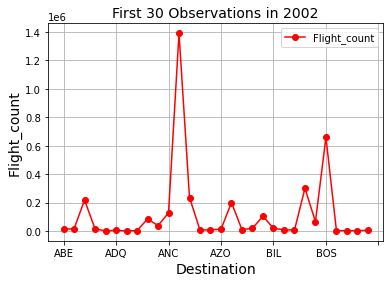

In [64]:
df4.head(30).plot(kind='line', x='Destination',y='Flight_count', color='red', marker='o')
plt.title('First 30 Observations in 2002', fontsize=14)
plt.xlabel('Destination', fontsize=14)
plt.ylabel('Flight_count', fontsize=14)
plt.grid(True)
plt.show()

In [ ]:
conn.close()